# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [25]:
# Standard library imports for this phase
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [26]:
# Load the prepared dataset from Phase 3
DATA_PATH = Path('../data/processed/flights_prepared_phase3.csv')

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 5714008 rows x 28 columns


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,...,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DELAY_15
0,2015,1,1,4,AS,98,ANC,SEA,5,205.0,...,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,0
1,2015,1,1,4,AA,2336,LAX,PBI,10,280.0,...,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,0
2,2015,1,1,4,US,840,SFO,CLT,20,286.0,...,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313,0
3,2015,1,1,4,AA,258,LAX,MIA,20,285.0,...,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056,0
4,2015,1,1,4,AS,135,SEA,ANC,25,235.0,...,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,0


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your data mining problem type (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [27]:
# TODO: Select and document your modelling techniques here.

modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "DELAY_15",
    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Provides a baseline for predicting whether a flight will be delayed by more than 15 minutes.",
            "assumptions": "Assumes a linear decision boundary in the transformed feature space; acceptable as a baseline after one-hot encoding of categorical variables."
        },
        {
            "name": "Decision Tree",
            "library": "sklearn.tree.DecisionTreeClassifier",
            "justification": "Captures non-linear interactions between schedule, route, and airport features and is easy to interpret.",
            "assumptions": "Makes few distributional assumptions, but can overfit if depth is not controlled."
        },
        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Provides a stronger ensemble benchmark that can model complex relationships and usually performs well on mixed operational data.",
            "assumptions": "Makes few distributional assumptions and reduces overfitting compared with a single tree through bagging."
        }
    ]
}

# Display the selected techniques
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print(f"\nCandidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']} - {model['justification']}")

Problem Type: Binary Classification
Target Variable: DELAY_15

Candidate Models:
  1. Logistic Regression - Provides a baseline for predicting whether a flight will be delayed by more than 15 minutes.
  2. Decision Tree - Captures non-linear interactions between schedule, route, and airport features and is easy to interpret.
  3. Random Forest - Provides a stronger ensemble benchmark that can model complex relationships and usually performs well on mixed operational data.


In [28]:
# Import the specific model classes you plan to use

print("Models imported for this notebook:")
print("- LogisticRegression")
print("- DecisionTreeClassifier")
print("- RandomForestClassifier")

Models imported for this notebook:
- LogisticRegression
- DecisionTreeClassifier
- RandomForestClassifier


---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [29]:
# TODO: Define your test design and split the data.

RANDOM_SEED = 42
TEST_SIZE = 0.2
MODEL_SAMPLE_SIZE = 200000

if len(df) > MODEL_SAMPLE_SIZE:
    df_model = df.sample(n=MODEL_SAMPLE_SIZE, random_state=RANDOM_SEED)
else:
    df_model = df.copy()

# Define features (X) and target (y)
TARGET_COL = 'DELAY_15'
feature_columns = [col for col in df_model.columns if col != TARGET_COL]

X = df_model[feature_columns]
y = df_model[TARGET_COL]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Perform the train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED,
    stratify=y
)

print(f"Working modelling sample: {df_model.shape[0]} rows")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nCategorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

Working modelling sample: 200000 rows
Training set: 160000 samples
Test set:     40000 samples

Categorical features: ['AIRLINE_CODE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'ORIGIN_COUNTRY', 'DESTINATION_AIRPORT_NAME', 'DESTINATION_CITY', 'DESTINATION_STATE', 'DESTINATION_COUNTRY']
Numerical features: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'FLIGHT_NUMBER', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'CANCELLED', 'DIVERTED', 'SCHEDULED_DEPARTURE_HOUR', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DESTINATION_LATITUDE', 'DESTINATION_LONGITUDE']


In [30]:
# Document and justify your test design
test_design = {
    "split_ratio": "80/20 split",
    "validation_strategy": "5-fold cross-validation on the selected best model",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": "An 80/20 hold-out split provides an unbiased test set, while stratification preserves the class balance of delayed and non-delayed flights. A sampled working dataset is used to keep the notebook practical on a local machine, and cross-validation is applied to the selected best model for additional reliability."
}
print(test_design)

{'split_ratio': '80/20 split', 'validation_strategy': '5-fold cross-validation on the selected best model', 'stratified': True, 'random_seed': 42, 'justification': 'An 80/20 hold-out split provides an unbiased test set, while stratification preserves the class balance of delayed and non-delayed flights. A sampled working dataset is used to keep the notebook practical on a local machine, and cross-validation is applied to the selected best model for additional reliability.'}


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [31]:
# TODO: Build and train your models.
# Store trained models in a dictionary for easy comparison.

preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numerical_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numerical_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
    ]
)

trained_models = {}

# --- Model 1 ---
model_1 = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'))
])
model_1.fit(X_train, y_train)
trained_models['Logistic Regression'] = model_1

# --- Model 2 ---
model_2 = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=12, min_samples_leaf=20, class_weight='balanced'))
])
model_2.fit(X_train, y_train)
trained_models['Decision Tree'] = model_2

# --- Model 3 ---
model_3 = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, n_jobs=-1, class_weight='balanced_subsample'))
])
model_3.fit(X_train, y_train)
trained_models['Random Forest'] = model_3

print(f"Successfully trained {len(trained_models)} model(s).")

Successfully trained 3 model(s).


In [32]:
# Optional: Hyperparameter tuning with GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [10, None],
    'classifier__min_samples_split': [2, 10],
    'classifier__min_samples_leaf': [1, 5],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor_tree),
        ('classifier', RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score:   {grid_search.best_score_:.4f}" )

trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV score:   0.6446


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [37]:
# TODO: Evaluate and compare all trained models.
# Build a results summary table.

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).set_index('Model')
print("=== Model Comparison ===")
print(results_df.round(4))

=== Model Comparison ===
                       Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                
Logistic Regression      0.6125     0.2543  0.6248    0.3614   0.6512
Random Forest (Tuned)    0.6017     0.2509  0.6388    0.3603   0.6548
Decision Tree            0.6091     0.2527  0.6269    0.3602   0.6513
Random Forest            0.8081     0.3441  0.1030    0.1585   0.6322



=== Best Model: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.61      0.72     32978
           1       0.25      0.62      0.36      7022

    accuracy                           0.61     40000
   macro avg       0.57      0.62      0.54     40000
weighted avg       0.77      0.61      0.66     40000



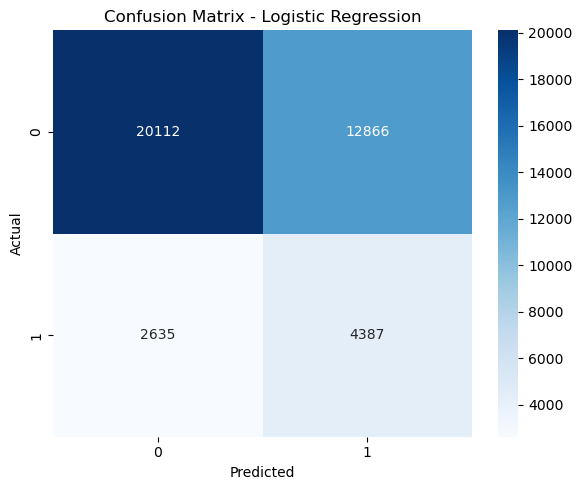

In [35]:
# Visualise results: Confusion Matrix for the best model (Classification)

best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [36]:
# Cross-validation for the selected best model

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1')
print(f"Cross-Validation F1 Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-Validation F1 Scores: [0.3591 0.3603 0.3626 0.3561 0.3608]
Mean: 0.3598 (+/- 0.0022)
